In [1]:
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False
# this is to turn off warnings as this is an older version of TensorFlow

## Step 1, Loading our Data

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('csvImages 10k x 784.csv')

### Converting our Data into a more readable format
We need to do this as these are all images as pixel valeus, and are coloured pixel value

In [4]:
# This function simply gathers the values and returns an array of values without column 
# seperation
data_array = data.values

In [5]:
# Checking what shape our array is
print(data_array.shape)
# should be 10000 images that are 28x28 or 784 pixels

(9999, 784)


In [6]:
# We are simply normalizing pixel values, essentially removing some colour depth
# for efficiency
normalized = data_array/255

In [7]:
import numpy as np
import matplotlib.pyplot as plt

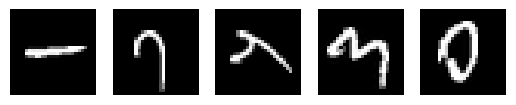

In [8]:
# Plotting the first 5 images
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(normalized[i].reshape(28, 28), cmap='gray')  # Reshape and use gray colormap
    plt.axis('off')   
plt.show()

In [9]:
normalized[1].shape

(784,)

This is already normalized and in the shape required for input into a neural network
 so moving on!
## Step 2, Modeling

In [10]:
from keras import layers, models
# getting layers and model libraries to build a nerual network


# it is funny to see this uses a backend of TensorFlow. Keras has entirely taken over TensorFlows Neural Network libs

Using TensorFlow backend.


In [11]:
# First lets make an input layer to gather our inputs, matching the shape from earlier
# this simply just sets specific limitations for our data inputs
input_layer = layers.Input(shape=(784,))

### Encoding

In [12]:
# now we begin setting up our encoding layers
encoding = layers.Dense(640, activation='relu')(input_layer)
encoding = layers.Dense(320, activation='relu')(encoding)
encoding = layers.Dense(160, activation='relu')(encoding)
encoding = layers.Dense(80, activation='relu')(encoding)
encodingFull = layers.Dense(32, activation='relu')(encoding)

What are we attempting to do

Why are we using Dense layers? Well Dense layers are the most popular and robust type of keras 
layer, being fully interconnected (essentially each neuron receives input from each previous neuron). These layers do not have specific requirements for input types and can be used to appraoch almost any task, though as a more generalist layer they are not perfect for any specific task when other options, like Convolution or Pooling layers, may be available. 

### Decoding

In [13]:
decoding = layers.Dense(32, activation='relu')(encodingFull)
decoding = layers.Dense(64, activation='relu')(decoding)
decoding = layers.Dense(128, activation='relu')(decoding)
decoding = layers.Dense(256, activation='relu')(decoding)
decoding = layers.Dense(784, activation='sigmoid')(decoding)

What are we actually doing? Why are we encoding and decoding? <br>
An autoencoder is a system designed to minimize image data and compress it without removing the important patterns, then learns to reconstruct the images using this compacted version. <br>
We encode the data to extract important features while reducing the dimensionality (size) of our image, ensuring that the data can be quickly processed by the model and that our data is in a machine readable format.<br>
We decode our data to essentially have the machine learn to reconstruct images from the extracted feature maps or decisional data that was generated from the encoder. 

### Compiling

In [14]:
model = models.Model(input_layer, decoding)
model.compile(loss='binary_crossentropy', optimizer='adam')

In [15]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 784)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 640)               502400    
_________________________________________________________________
dense_2 (Dense)              (None, 320)               205120    
_________________________________________________________________
dense_3 (Dense)              (None, 160)               51360     
_________________________________________________________________
dense_4 (Dense)              (None, 80)                12880     
_________________________________________________________________
dense_5 (Dense)              (None, 32)                2592      
_________________________________________________________________
dense_6 (Dense)              (None, 32)                1056      
__________

In [16]:
# Training our model
history = model.fit(normalized, normalized, epochs=30, batch_size=30)

Epoch 1/30
9999/9999 [==============================] - 5s 550us/step - loss: 0.2247
Epoch 2/30
9999/9999 [==============================] - 5s 466us/step - loss: 0.1527
Epoch 3/30
9999/9999 [==============================] - 5s 459us/step - loss: 0.1323
Epoch 4/30
9999/9999 [==============================] - 5s 510us/step - loss: 0.1196 0s 
Epoch 5/30
9999/9999 [==============================] - 5s 476us/step - loss: 0.1122
Epoch 6/30
9999/9999 [==============================] - 5s 485us/step - loss: 0.1069
Epoch 7/30
9999/9999 [==============================] - 5s 501us/step - loss: 0.1037
Epoch 8/30
9999/9999 [==============================] - 5s 475us/step - loss: 0.1006
Epoch 9/30
9999/9999 [==============================] - 5s 516us/step - loss: 0.0983
Epoch 10/30
9999/9999 [==============================] - 7s 662us/step - loss: 0.0966
Epoch 11/30
9999/9999 [==============================] - 6s 629us/step - loss: 0.0947 0s - loss: 0.0
Epoch 12/30
9999/9999 [=====================

We see that this model trained well, going from a loss of 0.2383 to 0.0874 in 30 epochs. 
This model is likely well fit but are we overfit?

#### Quickly what is a loss function?
To summarize without going into the complex mathematics, a loss function acts as a metric that indicates how well a model is preforming in classification or other tasks. It is the cumulation of the changes in weights and bias changes made by the optimizer


### Can we do better?
Potentially!<br>
If we were to reduce our neural count perhaps the system could be more robust but we can also try a different layers to attempt to ensure our model is best suited to this task. Our first model is likely a good fit already but now we begin to test and see if we can indeed create a more powerful model with stronger results! 

#### Using a reduced system that is better put together!

In [17]:
#Simply rebuilding our model with less layers and neurons
input_layer2 = layers.Input(shape=(784,))

# our new reduced encoding layer!
encoding2 = layers.Dense(256, activation='relu')(input_layer2)
encoding2 = layers.Dense(98, activation='relu')(encoding2)#increased to 98 in post, best I got
encodingFull2 = layers.Dense(32, activation='relu')(encoding2)


#Now setting up the decoding section!
decoding2 = layers.Dense(32, activation='relu')(encodingFull2)
decoding2 = layers.Dense(256, activation='relu')(decoding2)
decoding2 = layers.Dense(784, activation='sigmoid')(decoding2)

In [18]:
# reusing our old models optimizer and loss to ensure that things remain similar for comparison
model2 = models.Model(input_layer2, decoding2)
model2.compile(loss='binary_crossentropy', optimizer='adam')

In [19]:
model2.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 784)               0         
_________________________________________________________________
dense_11 (Dense)             (None, 256)               200960    
_________________________________________________________________
dense_12 (Dense)             (None, 98)                25186     
_________________________________________________________________
dense_13 (Dense)             (None, 32)                3168      
_________________________________________________________________
dense_14 (Dense)             (None, 32)                1056      
_________________________________________________________________
dense_15 (Dense)             (None, 256)               8448      
_________________________________________________________________
dense_16 (Dense)             (None, 784)               201488    
Total para

In [20]:
# Training our model again
history = model2.fit(normalized, normalized, epochs=30, batch_size=30)

Epoch 1/30
9999/9999 [==============================] - 3s 306us/step - loss: 0.2084
Epoch 2/30
9999/9999 [==============================] - 2s 207us/step - loss: 0.1259
Epoch 3/30
9999/9999 [==============================] - 2s 206us/step - loss: 0.1087
Epoch 4/30
9999/9999 [==============================] - 2s 212us/step - loss: 0.1016
Epoch 5/30
9999/9999 [==============================] - 2s 224us/step - loss: 0.0969
Epoch 6/30
9999/9999 [==============================] - 2s 203us/step - loss: 0.0935
Epoch 7/30
9999/9999 [==============================] - 2s 215us/step - loss: 0.0907
Epoch 8/30
9999/9999 [==============================] - 2s 218us/step - loss: 0.0886
Epoch 9/30
9999/9999 [==============================] - 2s 235us/step - loss: 0.0868
Epoch 10/30
9999/9999 [==============================] - 2s 234us/step - loss: 0.0853
Epoch 11/30
9999/9999 [==============================] - 2s 224us/step - loss: 0.0841
Epoch 12/30
9999/9999 [==============================] - 2s 216

Whoa! Perhaps we were overfit! This is a much better build than our first according to the 
loss functions. <br>
Perhaps this will be our best model for today! It also trains and calculates much faster than our original which is a huge improvement!

### Judging Performace
Let's look at model 2 to see how well it preformed!

In [21]:
encoder_output = models.Model(input_layer2, encodingFull2).predict(normalized[:5])

In [22]:
decoder_output = model2.predict(normalized[:5])

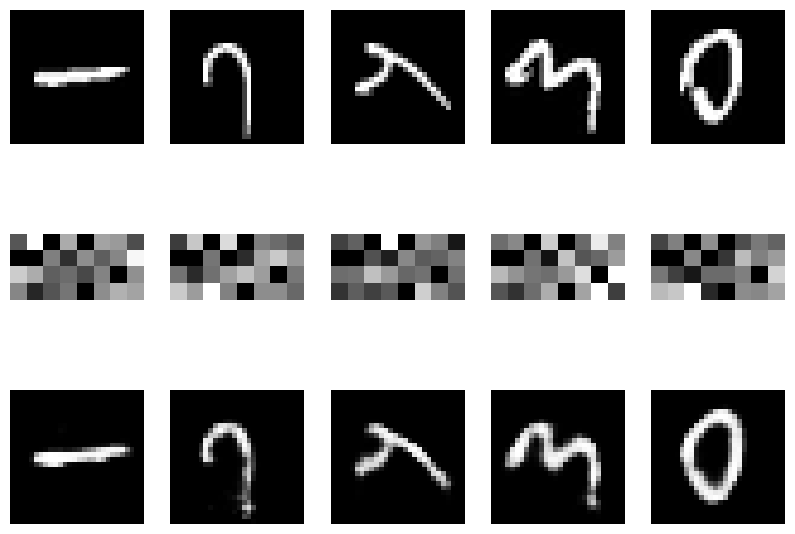

In [23]:
plt.figure(figsize=(10, 7))
for i in range(5):
    # Plot original digit images, this is copied from our textbook with minor modifications
    plt.subplot(3, 5, i + 1)
    plt.imshow(normalized[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    # Plot the encoder output
    plt.subplot(3, 5, i + 6)
    plt.imshow(encoder_output[i].reshape(4, 8), cmap='gray')
    plt.axis('off')   
    
    # Plot the decoder output
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoder_output[i].reshape(28, 28), cmap='gray')
    plt.axis('off') 
plt.show()

In [24]:
# Lets take a look to see if our original does any different!
encoder_output_or = models.Model(input_layer, encodingFull).predict(normalized[:5])

In [25]:
decoder_output_or = model.predict(normalized[:5])

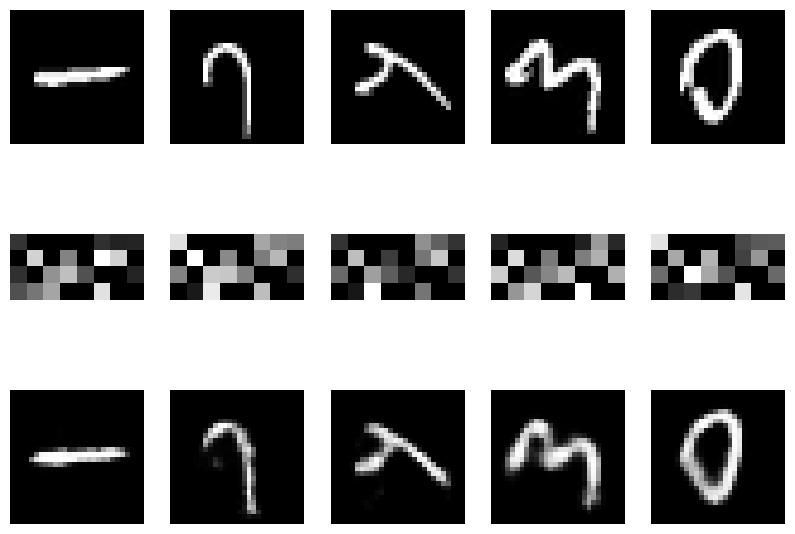

In [26]:
plt.figure(figsize=(10, 7))
for i in range(5):
    # Plot original digit images, this is copied from our textbook with minor modifications
    plt.subplot(3, 5, i + 1)
    plt.imshow(normalized[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    # Plot the encoder output
    plt.subplot(3, 5, i + 6)
    plt.imshow(encoder_output_or[i].reshape(4, 8), cmap='gray')
    plt.axis('off')   
    
    # Plot the decoder output
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoder_output_or[i].reshape(28, 28), cmap='gray')
    plt.axis('off') 
plt.show()

### Observations
Wow! Our second model produces cleaner images!! That is cool to see that our original model was generally producing less defined images than the first. Our original model seems to struggle with irregular shapes. It does suggest that the original was beginning to become overfit! Bigger isn't always better in Neural Networks! Model 2 does seemingly struggle with sharper lines, as we see a bit of blurring there, but otherwise it produces very clear and concise images which is what was required. And even though we see soem minor blurring on sharper lines the image is still very easily recognised. We could attempt to add some more neurons in an attempt to stop this and I may do this in the final compiling of this assignment. More training can also be used to improve our second model as well, since we see a a steady improvement rate in each epoch, though adding more than epochs will not solve the problem entirely as we see diminishing returns.<br><br>

** Update upon final compile: <br>
I have tweaked and edited a few different things, adding layers and expanding or minimizing the network to certain degrees and the original still worked best. I could not address the blurring issue with some of our representations sadly. I have gotten Model 2 to the best I can 

#### Why not use other layers?
Well I feel that using convolution layers in this assignment may be a bit overkill at this time, but convolution layers are very good for processing images and looking at spacial relations (how pixels form patterns over a plane vs a line) but to use convolution layers would require us to transform our input data immediately to reform the images, and that requires more computational power to both transform the data then the layers themselves are more resource intensive. We are looking at very simple usage cases that aren't high risk and we likely need to consider lower resource costs where we can. 

## How much Data is saved using the encoder method?
Well, we are told to assume a floating point takes around 4 bytes of data. So lets use some code to do the math cause I cannot be bothered!

In [27]:
# Original data size: 784 pixels per image, each pixel is a float (4 bytes)
original_size = 784 * 4  # 4 bytes per float
# We are looking at the full image size in bytes

# Encoded data size: using the encoded layer's output size (32 floats)
encoded_size = 32 * 4
# our encoder takes outputs an array of 32 'pixels' in it's encoding phase

# Calculate the percentage of memory saved
memory_saved = (1 - encoded_size / original_size) * 100
print(f"Memory saved per image: {memory_saved:.2f}%")# This was made by ChatGPT but I understand what is happening!
# this is more basic math, calculating a percentage then using a formatted string to insert the number rounded to 
# two decimal points

Memory saved per image: 95.92%
